## Problem Formulation and Data Ingestion

The objective of this project is to evaluate the effectiveness of sequential modeling approaches on real-world sentiment classification using the "To Vaccinate or Not to Vaccinate" dataset. The task requires categorizing social media posts into positive, neutral, or negative attitudes toward immunization.

To ensure empirical validity across all comparative experiments, this section of the notebook handles data loading, exploratory analysis, cleaning, and static data partitioning. Generating fixed splits at this stage guarantees that all baseline, recurrent, convolutional, and transformer models evaluate against an identical test set.

In [2]:
import pandas as pd
import numpy as np

# Defining the file path from the Kaggle input directory
file_path = '/kaggle/input/datasets/arsenekabasinga/to-vaccinate-or-not-to-vaccinate/Train.csv'

# Loading the raw dataset
df = pd.read_csv(file_path)

# Displaying dataset dimensions and initial structure
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Records:")
display(df.head())

# Inspecting column data types and missing values
print("\nMissing Values Count:")
print(df.isnull().sum())

print("\nRaw Label Distribution:")
print(df['label'].value_counts(dropna=False))

Dataset Shape: (10001, 4)

First 5 Records:


,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0



Missing Values Count:
tweet_id     0
safe_text    0
label        1
agreement    2
dtype: int64

Raw Label Distribution:
label
 0.000000    4908
 1.000000    4053
-1.000000    1038
 NaN            1
 0.666667       1
Name: count, dtype: int64


### Data Cleaning and Label Standardization

Exploratory inspection of the raw records reveals two primary data quality anomalies:
1. One record contains a missing target label (`NaN`).
2. One record contains an invalid non-discrete label (`0.666667`).

Because valid classification requires discrete target classes (-1 for Negative, 0 for Neutral, and 1 for Positive), anomalous and null records are pruned. 

Additionally, deep learning frameworks (such as PyTorch and TensorFlow) require categorical cross-entropy targets to be non-negative integers indexed from $0$ to $C-1$. Consequently, the labels are mapped as follows:
* `-1` (Negative) $\rightarrow$ `0`
* `0` (Neutral) $\rightarrow$ `1`
* `1` (Positive) $\rightarrow$ `2`

In [3]:
# Removing records with missing text or target labels
df_clean = df.dropna(subset=['safe_text', 'label']).copy()

# Retaining only valid sentiment labels: -1.0, 0.0, and 1.0
df_clean = df_clean[df_clean['label'].isin([-1.0, 0.0, 1.0])].copy()

# Casting text to string type to prevent downstream tokenizer failures
df_clean['safe_text'] = df_clean['safe_text'].astype(str)

# Mapping labels to 0, 1, 2 for cross-entropy compatibility
label_mapping = {-1.0: 0, 0.0: 1, 1.0: 2}
df_clean['label_idx'] = df_clean['label'].map(label_mapping).astype(int)

# Displaying post-cleaning distribution
print(f"Cleaned Dataset Shape: {df_clean.shape}")
print("\nStandardized Class Distribution (0=Negative, 1=Neutral, 2=Positive):")
print(df_clean['label_idx'].value_counts().sort_index())

Cleaned Dataset Shape: (9999, 5)

Standardized Class Distribution (0=Negative, 1=Neutral, 2=Positive):
label_idx
0    1038
1    4908
2    4053
Name: count, dtype: int64


### Stratified Data Partitioning

The cleaned records are partitioned into three independent subsets:
* **Training Set (70%):** Utilized for model parameter estimation and representation learning.
* **Validation Set (15%):** Utilized for hyperparameter tuning, regularization selection, and early stopping.
* **Test Set (15%):** Held out strictly for final metric reporting and cross-model comparison.

Stratified sampling is enforced using a fixed pseudo-random seed (`random_state=42`). Stratification guarantees that the proportional representation of each sentiment class remains uniform across all splits, preventing distribution shift between training and evaluation.

In [4]:
from sklearn.model_selection import train_test_split

# Initial partition: 85% train-validation combined, 15% holdout test
train_val_df, test_df = train_test_split(
    df_clean,
    test_size=0.15,
    random_state=42,
    stratify=df_clean['label_idx']
)

# Secondary partition: Split the 85% into 70% train and 15% validation
# (0.17647 of 85% is approximately 15% of the total dataset)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.17647,
    random_state=42,
    stratify=train_val_df['label_idx']
)

# Output partition dimensions
print(f"Training Instances:   {len(train_df)} ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"Validation Instances: {len(val_df)} ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"Test Instances:       {len(test_df)} ({len(test_df)/len(df_clean)*100:.1f}%)")

Training Instances:   6999 (70.0%)
Validation Instances: 1500 (15.0%)
Test Instances:       1500 (15.0%)


### Verification and Artifact Export

To verify the integrity of the stratified partitioning, class proportions are compared across the three subsets. Once verified, the data subsets are saved as static CSV files to the working directory. These files serve as the single source of truth across all subsequent modeling notebooks.

In [5]:
# Computing and verifying class proportions across all subsets
verification_df = pd.DataFrame({
    'Train (%)': train_df['label_idx'].value_counts(normalize=True).sort_index() * 100,
    'Validation (%)': val_df['label_idx'].value_counts(normalize=True).sort_index() * 100,
    'Test (%)': test_df['label_idx'].value_counts(normalize=True).sort_index() * 100
})
print("Class Distribution Comparison Across Splits:")
display(verification_df.round(2))

# Exporting static partitions to disk
train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)
test_df.to_csv('test_split.csv', index=False)

print("\nPartition files successfully exported: train_split.csv, val_split.csv, test_split.csv")

Class Distribution Comparison Across Splits:


,Train (%),Validation (%),Test (%)
label_idx,,,
0,10.37,10.40,10.40
1,49.09,49.07,49.07
2,40.53,40.53,40.53



Partition files successfully exported: train_split.csv, val_split.csv, test_split.csv


# Plotting the Sequence Length Distribution

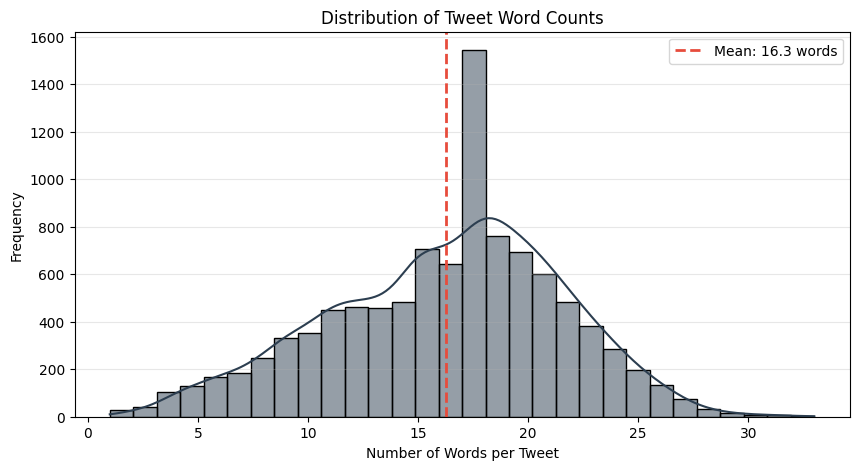

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculating word count for each tweet
df_clean['word_count'] = df_clean['safe_text'].apply(lambda x: len(str(x).split()))

# Plotting the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['word_count'], bins=30, kde=True, color='#2c3e50')

# Adding a line showing the average length
mean_length = df_clean['word_count'].mean()
plt.axvline(mean_length, color='#e74c3c', linestyle='dashed', linewidth=2, label=f'Mean: {mean_length:.1f} words')

plt.title('Distribution of Tweet Word Counts')
plt.xlabel('Number of Words per Tweet')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Sequence Length Distribution

The histogram demonstrates that the dataset consists of short texts. The average tweet is 16.3 words long, and the absolute maximum length is 33 words. This visualization directly informs the preprocessing strategy for the neural network models (GRU, Bi-LSTM, 1D-CNN): the sequence padding limit (`max_len`) will be set to exactly 35. This ensures no meaningful text is truncated while preventing wasted memory from excessive padding.

# Plotting the Vocabulary Noise (Top N-Grams)

/tmp/ipykernel_58/3403738375.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


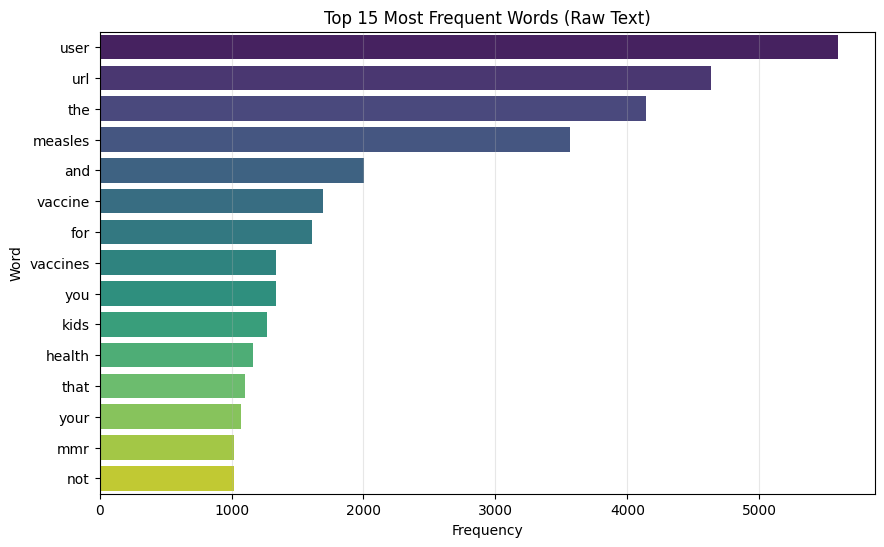

In [6]:
from collections import Counter
import re

# Extracting all words from the dataset, converting to lowercase
all_text = " ".join(df_clean['safe_text'].astype(str)).lower()
# Find words with 3 or more characters
all_words = re.findall(r'\b[a-z]{3,}\b', all_text)

# Getting the top 15 most frequent words
word_counts = Counter(all_words).most_common(15)
words, counts = zip(*word_counts)

# Plotting the top words
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')

plt.title('Top 15 Most Frequent Words (Raw Text)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Vocabulary and N-Gram Analysis

The frequency analysis exposes significant noise in the raw data. Synthetic tags like `<user>` and `<url>`, along with standard stop words (e.g., 'the', 'and'), heavily dominate the corpus. If passed directly into frequency-based models like Naive Bayes or SVM, these uninformative tokens would drown out actual sentiment drivers like 'vaccine', 'measles', and 'health'. This visual evidence justifies the decision to explicitly strip these tags and remove English stop words during the TF-IDF vectorization phase.

### Feature Engineering: TF-IDF Vectorization

Because traditional machine learning models cannot process raw text, the textual data must be converted into numerical matrices. Based on the findings from the Exploratory Data Analysis, the synthetic placeholder tags `<user>` and `<url>` act as high-frequency noise. These tags are stripped from the corpus using regular expressions.

The cleaned text is then transformed using Term Frequency-Inverse Document Frequency (TF-IDF). To prevent the models from overfitting to rare words, the vocabulary is restricted to the top 10,000 features. Standard English stop words are removed, and the `ngram_range` is set to (1, 2) to capture both individual words and meaningful two-word phrases (e.g., "causes autism").

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Loading standardized splits
train_df = pd.read_csv('https://raw.githubusercontent.com/KABASINGAarsene/ML-TEC-1-Formative-2/main/Split%20data/train_split.csv')
val_df = pd.read_csv('https://raw.githubusercontent.com/KABASINGAarsene/ML-TEC-1-Formative-2/main/Split%20data/val_split.csv')
test_df = pd.read_csv('https://raw.githubusercontent.com/KABASINGAarsene/ML-TEC-1-Formative-2/main/Split%20data/test_split.csv')

# Extracting text and targets
X_train_raw, y_train = train_df['safe_text'], train_df['label_idx']
X_test_raw, y_test = test_df['safe_text'], test_df['label_idx']

# Removing <user> and <url> tags identified as noise during EDA
X_train_clean = X_train_raw.str.replace(r'<user>|<url>', '', regex=True)
X_test_clean = X_test_raw.str.replace(r'<user>|<url>', '', regex=True)

# Initializing TF-IDF Vectorizer with parameters informed by EDA
tfidf = TfidfVectorizer(
    stop_words='english', 
    ngram_range=(1, 2), 
    max_features=10000
)

# Fitting on training data and transform both sets into sparse numerical matrices
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print(f"TF-IDF Matrix Shape (Train): {X_train_tfidf.shape}")
print(f"TF-IDF Matrix Shape (Test):  {X_test_tfidf.shape}")

TF-IDF Matrix Shape (Train): (6999, 10000)
TF-IDF Matrix Shape (Test):  (1500, 10000)


### Baseline Model 1: Multinomial Naive Bayes

Multinomial Naive Bayes serves as the first baseline. It is a probabilistic classifier based on applying Bayes' theorem with strong independence assumptions between features. It is highly computationally efficient and provides a standard performance floor for text classification tasks where word order is ignored.

Naive Bayes Macro F1-Score: 0.5128

Classification Report:
              precision    recall  f1-score   support

Negative (0)       1.00      0.03      0.06       156
 Neutral (1)       0.77      0.78      0.77       736
Positive (2)       0.64      0.79      0.71       608

    accuracy                           0.70      1500
   macro avg       0.80      0.53      0.51      1500
weighted avg       0.74      0.70      0.67      1500



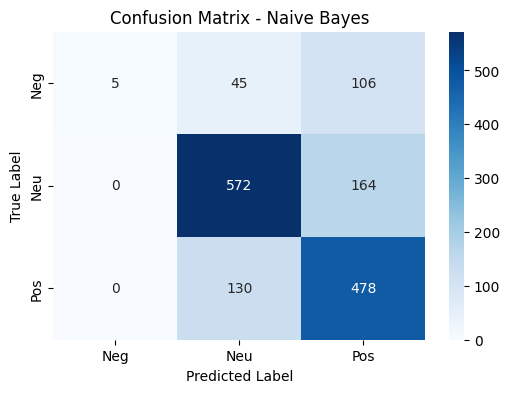

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Initialize and train the Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Generate predictions on the holdout test set
nb_preds = nb_model.predict(X_test_tfidf)

# Evaluate performance
nb_macro_f1 = f1_score(y_test, nb_preds, average='macro')
print(f"Naive Bayes Macro F1-Score: {nb_macro_f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, nb_preds, target_names=['Negative (0)', 'Neutral (1)', 'Positive (2)']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, nb_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Naive Bayes Error Analysis

The Multinomial Naive Bayes model achieves 70% accuracy but a low Macro F1-Score of 0.5128. The confusion matrix reveals a severe bias against the minority class: out of 156 actual Negative tweets, the model correctly identifies only 5. The remaining 151 Negative tweets are misclassified as Neutral or Positive. This failure occurs because the algorithm relies heavily on word counting, causing it to favor the majority categories and ignore the rare Negative sentiment.
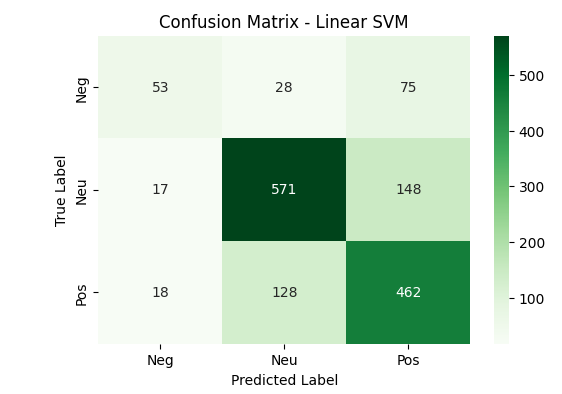

### Baseline Model 2: Linear Support Vector Machine (SVM)

To establish a more robust baseline, a Linear Support Vector Machine (LinearSVC) is implemented. SVMs attempt to find the optimal mathematical hyperplane that maximizes the margin between different classes. They are notoriously effective in high-dimensional sparse spaces, such as those created by TF-IDF vectorization, and tend to handle class imbalances better than simple probabilistic models.

Linear SVM Macro F1-Score: 0.6432

Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.60      0.34      0.43       156
 Neutral (1)       0.79      0.78      0.78       736
Positive (2)       0.67      0.76      0.71       608

    accuracy                           0.72      1500
   macro avg       0.69      0.63      0.64      1500
weighted avg       0.72      0.72      0.72      1500



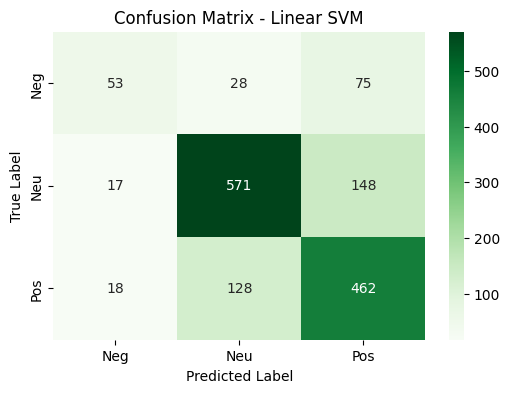

In [10]:
from sklearn.svm import LinearSVC

# Initialize and train the Linear SVM classifier
svm_model = LinearSVC(random_state=42, dual=False)
svm_model.fit(X_train_tfidf, y_train)

# Generate predictions
svm_preds = svm_model.predict(X_test_tfidf)

# Evaluate performance
svm_macro_f1 = f1_score(y_test, svm_preds, average='macro')
print(f"Linear SVM Macro F1-Score: {svm_macro_f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, svm_preds, target_names=['Negative (0)', 'Neutral (1)', 'Positive (2)']))

# Plot Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.title('Confusion Matrix - Linear SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Linear SVM Error Analysis

The Linear SVM improves the Macro F1-Score to 0.6432. The confusion matrix demonstrates much better handling of the imbalanced data, correctly identifying 53 of the 156 Negative tweets and raising recall to 34%. Because SVMs separate categories using structural boundaries rather than simple word frequencies, they isolate negative sentiment vocabulary more effectively. However, the remaining misclassifications show the natural limits of models that cannot read word order or context.

## Evaluation, Baseline Performance, and Comparative Discussion

### 1. Evaluation Metric Justification
The classification performance is evaluated using **Macro F1-Score** alongside overall Accuracy. Given the class distribution (approximately 10% Negative, 49% Neutral, and 41% Positive)[cite: 8], standard Accuracy is insufficient; an uncalibrated classifier can score 70% or higher simply by memorizing majority classes while failing the minority sentiment. The Macro F1-Score calculates the unweighted arithmetic mean of F1-scores across all three classes, applying an equal penalty to errors regardless of class frequency. This ensures that a model's capacity to isolate anti-vaccination sentiment is measured rigorously.

---

### 2. Baseline Model Performance Summary
The following table summarizes the evaluation metrics on the identical 1,500-instance holdout test set:

| Model Architecture | Feature Representation | Accuracy | Macro Precision | Macro Recall | Macro F1-Score | Negative (Class 0) Recall |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Multinomial Naive Bayes** | TF-IDF (1-2 n-grams) | 0.70 | 0.80 | 0.53 | **0.5128** | 0.03 |
| **Linear SVM (LinearSVC)** | TF-IDF (1-2 n-grams) | 0.72 | 0.69 | 0.63 | **0.6432** | 0.34 |

---

### 3. Discussion, Trade-offs, and Limitations
* **Probabilistic Failure vs. Maximum-Margin Boundaries:** Multinomial Naive Bayes demonstrates high overall accuracy (70%) but severe operational failure on the minority class, retrieving only 5 of 156 Negative instances (recall: 0.03)[cite: 14]. The algorithm's strong independence assumption and reliance on class prior probabilities skew decisions toward majority categories. In contrast, Linear SVM constructs an optimal hyperplane based on boundary instances, expanding Negative class recall tenfold to 34% (53 of 156 instances retrieved) and raising the Macro F1-Score to 0.6432[cite: 15].
* **Feature Representation Bottleneck:** While the Linear SVM achieves a competitive baseline, both architectures suffer from an intrinsic structural constraint: **TF-IDF ignores sequential order and syntactic dependencies**. By treating text as an unordered bag of tokens, non-sequential models fail on linguistic phenomena such as negation scope (*"not bad"* vs. *"not good"*), temporal shifts, and conversational sarcasm.
* **Experimental Progression:** The 0.64 Macro F1 ceiling established by Linear SVM highlights the necessity of contextual representation. These empirical findings justify progressing to sequential neural architectures (1D-CNN, GRU, Bi-LSTM, and Attention-based networks) that preserve token order and learn temporal semantic dependencies.